In [10]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [11]:
df = pd.read_csv("Telco-Customer-Churn.csv")
df.shape
df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [4]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [12]:
df.duplicated().sum()

np.int64(0)

In [5]:
df.drop("customerID", axis=1, inplace=True)

Observation
No significant missing values were found after conversion. CustomerID was removed because it does not contribute to analytical insights.

In [6]:
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

In [14]:
df.describe()
df.describe(include="object")

,customerID,gender,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,TotalCharges,Churn
count,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043
unique,7043,2,2,2,2,3,3,3,3,3,3,3,3,3,2,4,6531,2
top,7590-VHVEG,Male,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,20.2,No
freq,1,3555,3641,4933,6361,3390,3096,3498,3088,3095,3473,2810,2785,3875,4171,2365,11,5174


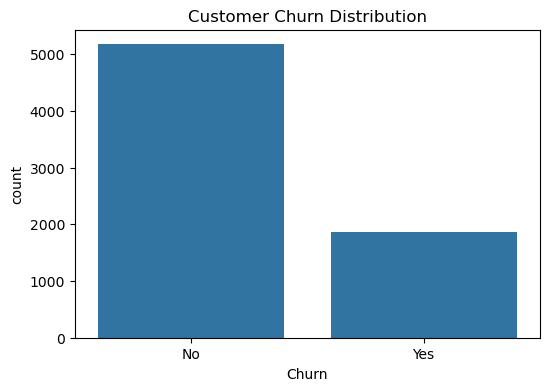

In [21]:
plt.figure(figsize=(6,4))
sns.countplot(
    x="Churn",
    data=df
)
plt.title("Customer Churn Distribution")
plt.savefig("churn_distribution.png")
plt.show()


Interpretation
The majority of customers remained with the company, while a smaller portion churned. This indicates that customer retention is generally strong but there is still a significant churn segment requiring attention.

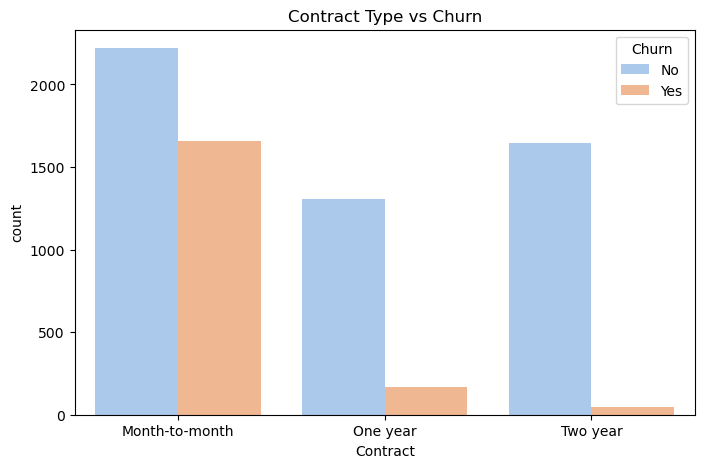

In [26]:
plt.figure(figsize=(8,5))

sns.countplot(x="Contract",
              hue="Churn",
              data=df,
              palette="pastel"
             )
plt.title("Contract Type vs Churn")
plt.show()

Customers on month-to-month contracts exhibit substantially higher churn rates compared with customers on one-year and two-year contracts.

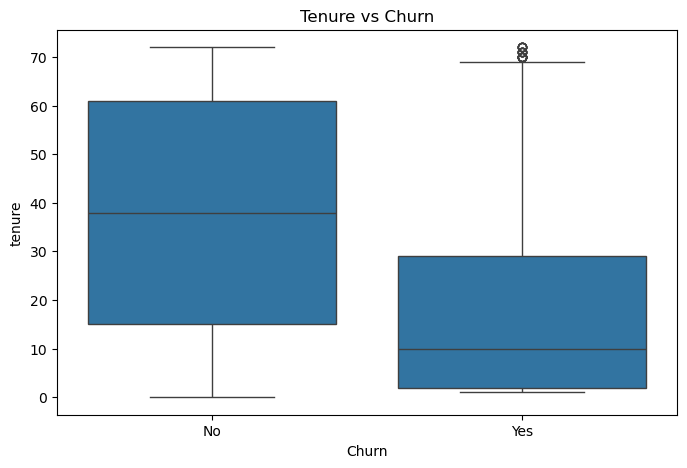

In [31]:
plt.figure(figsize=(8,5))

sns.boxplot(
    y="tenure",
    x="Churn",
    data=df
)

plt.title("Tenure vs Churn")
plt.show()

Customers who churn generally have shorter tenure, suggesting that churn is more common among newer customers.

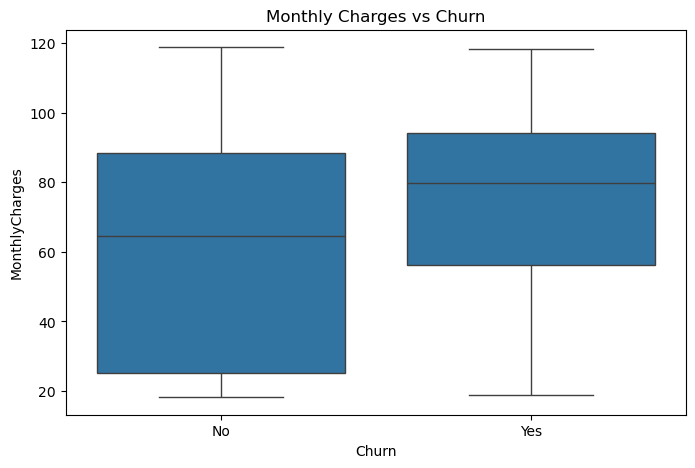

In [32]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x="Churn",
    y="MonthlyCharges",
    data=df
)

plt.title("Monthly Charges vs Churn")
plt.show()

Customers with higher monthly charges appear more likely to churn, indicating potential pricing concerns.

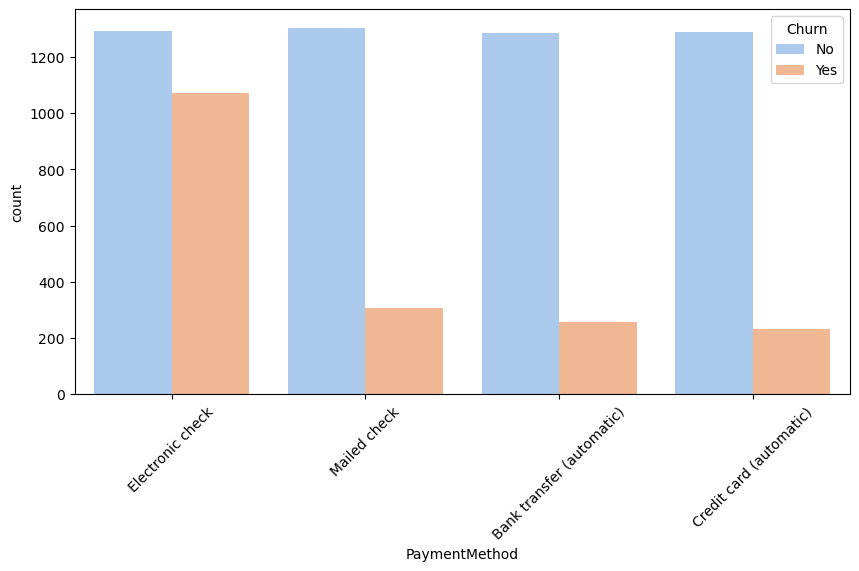

In [36]:
plt.figure(figsize=(10,5))

sns.countplot(
    x="PaymentMethod",
    hue="Churn",
    data=df,
    palette="pastel"
)

plt.xticks(rotation=45)
plt.show()

Certain payment methods show higher churn rates than others, suggesting a possible relationship between payment convenience and retention.

<Axes: xlabel='InternetService', ylabel='count'>

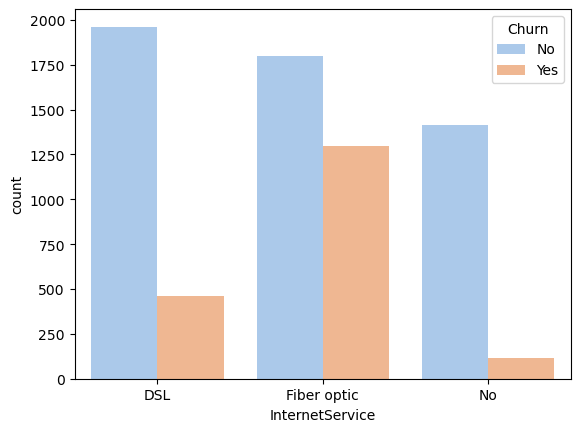

In [37]:
sns.countplot(
    x="InternetService",
    hue="Churn",
    palette="pastel",
    data=df
)

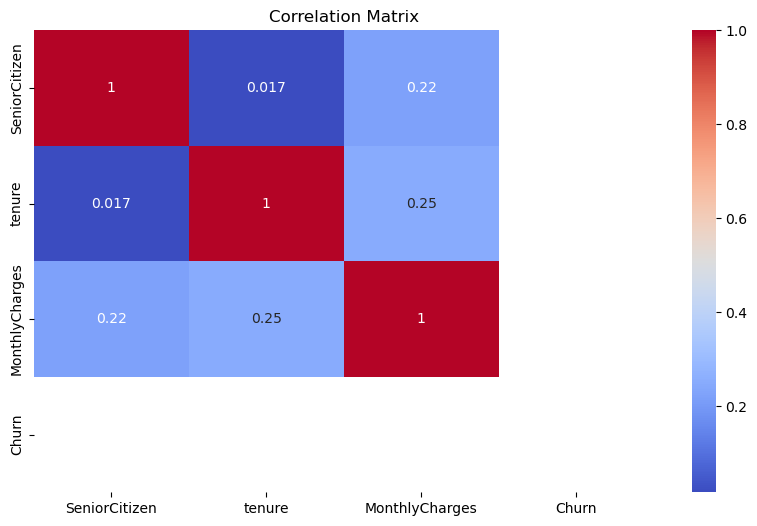

In [39]:
df["Churn"] = df["Churn"].map(
    {"No":0,"Yes":1}
)

plt.figure(figsize=(10,6))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Matrix")
plt.show()